<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/DL/Batch_vs_stochastic_GD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od

In [3]:
od.download('https://www.kaggle.com/datasets/akram24/social-network-ads')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: g65ashaharier21031
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/akram24/social-network-ads


100%|██████████| 3.27k/3.27k [00:00<00:00, 8.28MB/s]

In [4]:
import numpy as np
import pandas as pd
import time

In [5]:
df = pd.read_csv('/content/social-network-ads/Social_Network_Ads.csv')

In [6]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [7]:
df = df[['Age','EstimatedSalary','Purchased']]

In [8]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [9]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_scaled.shape

(400, 2)

In [13]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [14]:
model = Sequential()

model.add(Dense(10, activation='relu', input_dim=2))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss = 'binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [17]:
start = time.time()
history = model.fit(X, y, epochs=500, batch_size=1, validation_split=0.2)
print(time.time() - start)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6203 - loss: 810.4207 - val_accuracy: 0.3625 - val_loss: 34.1375
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5778 - loss: 47.4651 - val_accuracy: 0.3625 - val_loss: 104.5710
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5273 - loss: 45.1087 - val_accuracy: 0.3625 - val_loss: 11.6626
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5738 - loss: 26.6074 - val_accuracy: 0.3625 - val_loss: 38.3440
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5744 - loss: 35.3972 - val_accuracy: 0.6375 - val_loss: 17.0882
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5128 - loss: 42.7318 - val_accuracy: 0.3625 - val_loss: 17.8017
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5165 - loss: 52.0148 - val_accuracy: 0.3625 - val_loss: 37.7238
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6002 - loss: 2

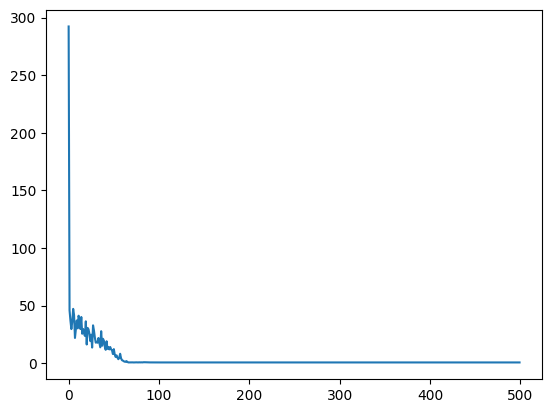

In [18]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])


In [19]:
model1 = Sequential()

model1.add(Dense(10,activation='relu',input_dim=2))
model1.add(Dense(10,activation='relu'))
model1.add(Dense(1,activation='sigmoid'))

In [20]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
model1.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history1 = model1.fit(X_scaled,y,epochs=500,batch_size=400,validation_split=0.2)
print(time.time() - start)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7375 - loss: 0.6378 - val_accuracy: 0.4250 - val_loss: 0.7572
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.7500 - loss: 0.6309 - val_accuracy: 0.4375 - val_loss: 0.7523
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7812 - loss: 0.6259 - val_accuracy: 0.4625 - val_loss: 0.7484
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.7969 - loss: 0.6217 - val_accuracy: 0.4625 - val_loss: 0.7450
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7937 - loss: 0.6179 - val_accuracy: 0.5000 - val_loss: 0.7419
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.7969 - loss: 0.6143 - val_accuracy: 0.5000 - val_loss: 0.7390
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8031 - loss: 0.6110 - val_accuracy: 0.5000 - val_loss: 0.7363
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8031 - loss: 0.6078 - val_accuracy: 0.5000 - val_

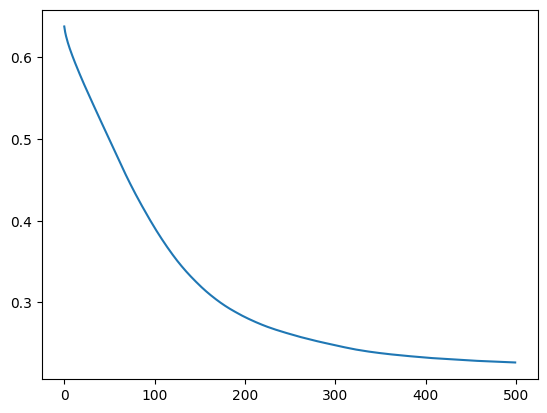

In [22]:
import matplotlib.pyplot as plt
plt.plot(history1.history['loss'])